# 09 — County Commissioner D2 spending descriptives (2026)

Simple descriptive analysis of 2026 ORESTAR spending for Multnomah County
Commissioner District 2.

We focus on total spending, expenditure-record counts, minimum/maximum values,
quartiles, mean, median, and candidate/source differences.


## 1. Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 190)

cwd = Path.cwd().resolve()

ROOT = cwd
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError(
            "Could not find repository root. "
            "Expected a pyproject.toml file somewhere above this notebook."
        )
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from helpers.paths import (
    CLEAN,
    PROCESSED,
    fundraising_processed_dir,
    orestar_file_audit_path,
    orestar_transactions_path,
    spending_processed_dir,
)

print("ROOT:", ROOT)

YEAR = 2026
CONTEST = "county_commissioner"

TRANSACTIONS_PATH = orestar_transactions_path(
    YEAR,
    CONTEST,
)

AUDIT_PATH = orestar_file_audit_path(
    YEAR,
    CONTEST,
)

OUTPUT_DIR = spending_processed_dir(
    YEAR,
    CONTEST,
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Transactions:", TRANSACTIONS_PATH)
print("Output:", OUTPUT_DIR)


ROOT: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis
Transactions: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/clean/orestar/2026/county_commissioner/transactions.csv
Output: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/spending/2026/county_commissioner


## 2. Load County Commissioner ORESTAR

In [2]:
def to_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes"])
    )

transactions = pd.read_csv(
    TRANSACTIONS_PATH,
    low_memory=False,
)

if set(
    transactions["contest_type"]
    .dropna()
    .astype(str)
    .unique()
) != {CONTEST}:
    raise ValueError(
        "Expected only county_commissioner transactions."
    )

display(
    transactions["sub_type"]
    .value_counts(dropna=False)
    .to_frame("rows")
)


,rows
sub_type,
Cash Contribution,473
Cash Expenditure,313
Personal Expenditure for Reimbursement,37
In-Kind Contribution,13
Account Payable,8
Return or Refund of Contribution,5
Refunds and Rebates,1
Miscellaneous Other Disbursement,1
Interest/Investment Income,1


## 3. Positive reported expenditures

In [3]:
transactions["reported_expenditure_amount"] = pd.to_numeric(
    transactions["reported_expenditure_amount"],
    errors="coerce",
)

spending = transactions.loc[
    to_bool(
        transactions["is_reported_expenditure"]
    )
    & transactions["reported_expenditure_amount"].notna()
    & transactions["reported_expenditure_amount"].gt(0)
].copy()

spending["amount"] = (
    spending["reported_expenditure_amount"]
)

spending["candidate"] = (
    spending["source_file_stem"]
    .astype(str)
    .str.strip()
)

print("Expenditure records:", f"{len(spending):,}")
print("Total spending:", f"${spending['amount'].sum():,.2f}")


Expenditure records: 351
Total spending: $182,871.48


## 4. Overall spending descriptives

In [4]:
overall_summary = pd.DataFrame(
    {
        "year": [YEAR],
        "contest_type": [CONTEST],
        "candidate_source_count": [
            spending["candidate"].nunique()
        ],
        "expenditure_count": [
            len(spending)
        ],
        "total_spending": [
            spending["amount"].sum()
        ],
        "min_expenditure": [
            spending["amount"].min()
        ],
        "q25_expenditure": [
            spending["amount"].quantile(0.25)
        ],
        "median_expenditure": [
            spending["amount"].median()
        ],
        "mean_expenditure": [
            spending["amount"].mean()
        ],
        "q75_expenditure": [
            spending["amount"].quantile(0.75)
        ],
        "max_expenditure": [
            spending["amount"].max()
        ],
        "std_expenditure": [
            spending["amount"].std()
        ],
    }
)

display(overall_summary.T)

display(
    spending["amount"]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
    .rename("value")
    .to_frame()
)


,0
year,2026
contest_type,county_commissioner
candidate_source_count,5
expenditure_count,351
total_spending,182871.48
min_expenditure,0.18
q25_expenditure,17.5
median_expenditure,99.0
mean_expenditure,521.001368
q75_expenditure,388.4


,value
count,351.000000
mean,521.001368
std,1625.727017
min,0.180000
10%,1.980000
25%,17.500000
50%,99.000000
75%,388.400000
90%,1452.000000
max,24485.000000


## 5. Candidate/source-level spending descriptives

In [5]:
candidate_summary = (
    spending
    .groupby(
        [
            "year",
            "contest_type",
            "office",
            "district",
            "candidate",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        total_spending=("amount", "sum"),
        expenditure_count=("amount", "size"),
        min_expenditure=("amount", "min"),
        q25_expenditure=("amount", lambda x: x.quantile(0.25)),
        mean_expenditure=("amount", "mean"),
        median_expenditure=("amount", "median"),
        q75_expenditure=("amount", lambda x: x.quantile(0.75)),
        max_expenditure=("amount", "max"),
        std_expenditure=("amount", "std"),
    )
    .sort_values(
        "total_spending",
        ascending=False,
    )
)

display(candidate_summary)


,year,contest_type,office,district,candidate,total_spending,expenditure_count,min_expenditure,q25_expenditure,mean_expenditure,median_expenditure,q75_expenditure,max_expenditure,std_expenditure
4,2026,county_commissioner,Multnomah County Commissioner,2,Zaghloul,110438.63,178,0.18,60.0000,620.441742,202.915,589.6500,24485.00,1938.815432
1,2026,county_commissioner,Multnomah County Commissioner,2,Greene,53403.17,68,0.87,26.0000,785.340735,115.000,701.4100,12500.00,1746.051034
0,2026,county_commissioner,Multnomah County Commissioner,2,Cruz,8963.60,12,24.60,103.6275,746.966667,277.440,645.6675,5328.00,1473.835277
2,2026,county_commissioner,Multnomah County Commissioner,2,Norris,8585.45,50,0.40,6.2075,171.709000,26.330,99.1800,2345.25,399.145125
3,2026,county_commissioner,Multnomah County Commissioner,2,Williams,1480.63,43,0.70,1.7500,34.433256,3.950,9.6250,390.00,89.179962


## 6. Candidate-level variable descriptives

In [6]:
display(
    candidate_summary[
        [
            "total_spending",
            "expenditure_count",
            "min_expenditure",
            "mean_expenditure",
            "median_expenditure",
            "max_expenditure",
        ]
    ]
    .describe()
    .T
)


,count,mean,std,min,25%,50%,75%,max
total_spending,5.0,36574.29600,46142.286096,1480.630000,8585.450,8963.600000,53403.170000,110438.630000
expenditure_count,5.0,70.20000,63.562568,12.000000,43.000,50.000000,68.000000,178.000000
min_expenditure,5.0,5.35000,10.764372,0.180000,0.400,0.700000,0.870000,24.600000
mean_expenditure,5.0,471.77828,345.493534,34.433256,171.709,620.441742,746.966667,785.340735
median_expenditure,5.0,125.12700,115.971431,3.950000,26.330,115.000000,202.915000,277.440000
max_expenditure,5.0,9009.65000,9797.144239,390.000000,2345.250,5328.000000,12500.000000,24485.000000


## 7. Spending by ORESTAR subtype

In [7]:
spending_type_summary = (
    spending
    .groupby(
        "sub_type",
        as_index=False,
        dropna=False,
    )
    .agg(
        expenditure_count=("amount", "size"),
        total_spending=("amount", "sum"),
        min_expenditure=("amount", "min"),
        mean_expenditure=("amount", "mean"),
        median_expenditure=("amount", "median"),
        max_expenditure=("amount", "max"),
    )
    .sort_values(
        "total_spending",
        ascending=False,
    )
)

spending_type_summary["spending_share"] = (
    spending_type_summary["total_spending"]
    / spending_type_summary["total_spending"].sum()
)

display(spending_type_summary)


,sub_type,expenditure_count,total_spending,min_expenditure,mean_expenditure,median_expenditure,max_expenditure,spending_share
0,Cash Expenditure,313,169863.71,0.18,542.695559,108.83,24485.0,0.928869
2,Personal Expenditure for Reimbursement,37,12707.77,12.00,343.453243,58.81,3000.0,0.069490
1,Miscellaneous Other Disbursement,1,300.00,300.00,300.000000,300.00,300.0,0.001640


## 8. Quick plots

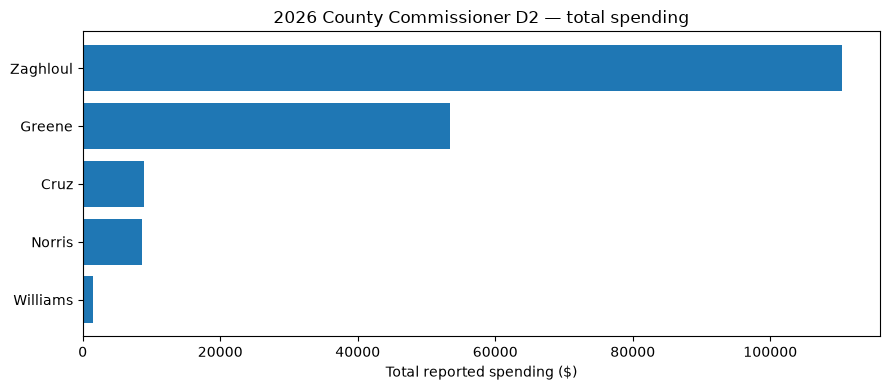

In [8]:
plot_table = candidate_summary.sort_values(
    "total_spending",
    ascending=True,
)

fig, ax = plt.subplots(
    figsize=(
        9,
        max(
            4,
            0.45 * len(plot_table),
        ),
    )
)

ax.barh(
    plot_table["candidate"],
    plot_table["total_spending"],
)

ax.set_xlabel("Total reported spending ($)")
ax.set_ylabel("")
ax.set_title(
    "2026 County Commissioner D2 — total spending"
)

plt.tight_layout()
plt.show()


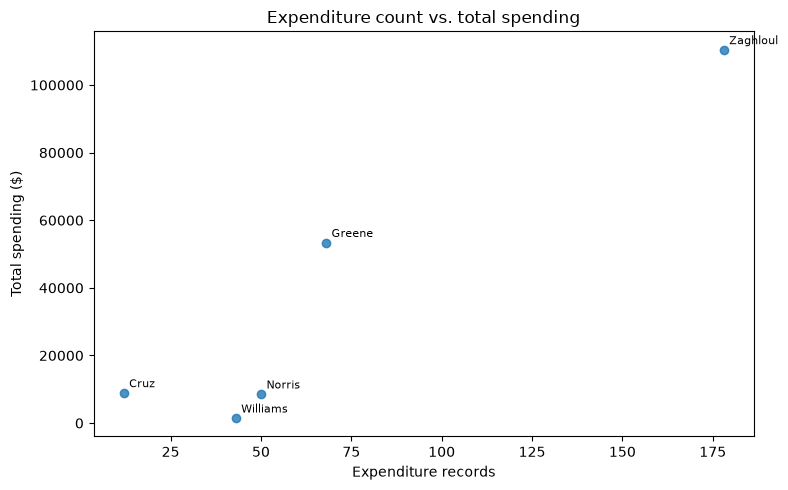

In [9]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.scatter(
    candidate_summary["expenditure_count"],
    candidate_summary["total_spending"],
    alpha=0.8,
)

for _, row in candidate_summary.iterrows():
    ax.annotate(
        row["candidate"],
        (
            row["expenditure_count"],
            row["total_spending"],
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Expenditure records")
ax.set_ylabel("Total spending ($)")
ax.set_title(
    "Expenditure count vs. total spending"
)

plt.tight_layout()
plt.show()


## 9. Source audit

In [10]:
if AUDIT_PATH.exists():
    audit = pd.read_csv(
        AUDIT_PATH,
        low_memory=False,
    )

    duplicate_exports = audit.loc[
        to_bool(
            audit["is_exact_duplicate_export"]
        )
    ].copy()

    print(
        "Exact duplicate export rows:",
        len(duplicate_exports),
    )

    if len(duplicate_exports):
        display(duplicate_exports)


Exact duplicate export rows: 0


## 10. Export

In [11]:
candidate_path = (
    OUTPUT_DIR
    / "candidate_spending_summary.csv"
)

overall_path = (
    OUTPUT_DIR
    / "overall_spending_summary.csv"
)

type_path = (
    OUTPUT_DIR
    / "spending_type_summary.csv"
)

candidate_summary.to_csv(
    candidate_path,
    index=False,
)

overall_summary.to_csv(
    overall_path,
    index=False,
)

spending_type_summary.to_csv(
    type_path,
    index=False,
)

print("SAVED", candidate_path)
print("SAVED", overall_path)
print("SAVED", type_path)


SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/spending/2026/county_commissioner/candidate_spending_summary.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/spending/2026/county_commissioner/overall_spending_summary.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/spending/2026/county_commissioner/spending_type_summary.csv
